### Задача

Задачу сегментации медицинских снимков. 

* Построй бейзлайн!
  * BCE Loss 
  * SegNet 
  * Train
  * Test 
* Мир других лоссов!
  * Dice Loss 
  * Focal Loss 
  * BONUS: лосс из статьи
* Новая модель!
  * UNet



In [1]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# Загрузка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>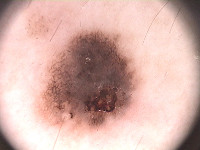</td><td>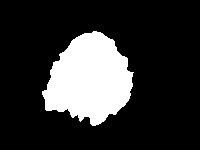</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [7]:
from pathlib import Path

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import numpy as np

# from torchvision.transforms import transforms
import albumentations as A

import matplotlib.pyplot as plt

from torchmetrics import JaccardIndex

from torch import nn


In [8]:
path = Path('./PH2Dataset')
images = sorted(path.rglob(pattern=r'IMD*/IMD*Dermoscopic_Image/*.bmp'))
masks = sorted(path.rglob(pattern=r'IMD*/IMD*lesion/*.bmp'))

In [9]:
train_ims, val_ims, train_mks, val_mks = train_test_split(images, masks, test_size=0.2, shuffle=True)
train_ims[0], train_mks[0]

(PosixPath('PH2Dataset/PH2 Dataset images/IMD421/IMD421_Dermoscopic_Image/IMD421.bmp'),
 PosixPath('PH2Dataset/PH2 Dataset images/IMD421/IMD421_lesion/IMD421_lesion.bmp'))

In [109]:
class MyDataset(Dataset):
    def __init__(self, images, masks, transform):
        super().__init__()
        self.images = images
        self.masks = masks
        self.transform = transform
            
    def __getitem__(self, ind):
        img = Image.open(self.images[ind])
        msk = Image.open(self.masks[ind])

        img = np.array(img)
        msk = np.array(msk).astype(int)

        aug_img_msk = self.transform(image=img, mask=msk)
        img, msk = aug_img_msk['image'], aug_img_msk['mask']

        return img, msk
    
    def __len__(self):
        return len(self.images)

In [110]:
transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(0.5),
    A.pytorch.ToTensorV2()
])
trainset = MyDataset(train_ims, train_mks, transform)
valset = MyDataset(val_ims, val_mks, transform)

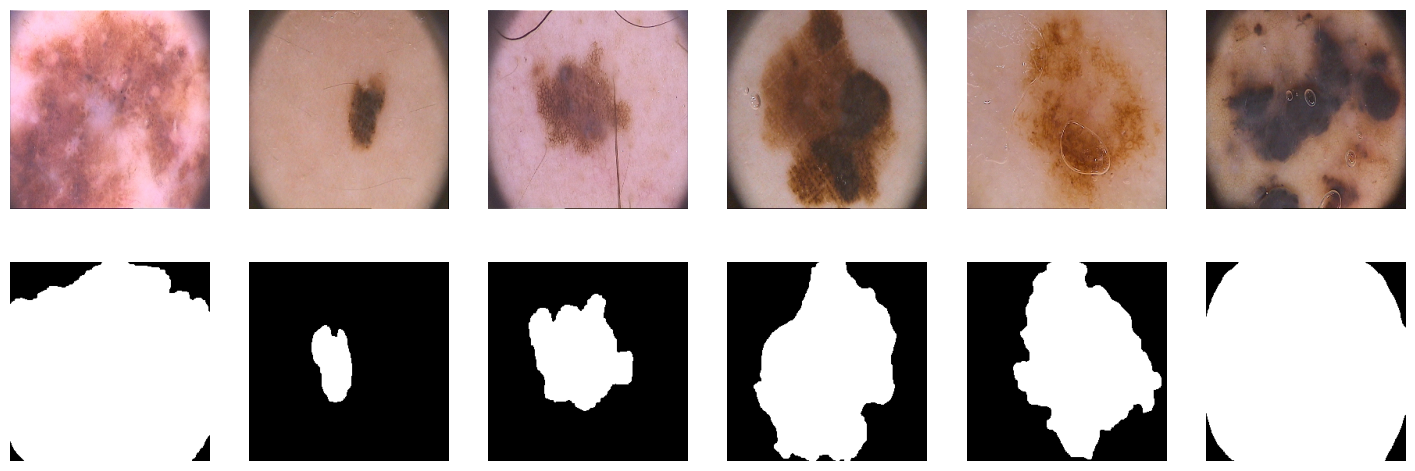

In [112]:
plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(trainset[i][0].numpy().transpose(1, 2, 0))

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(trainset[i][1].numpy(), cmap='grey')
plt.show()

## PyTorch DataLoader

In [113]:
tr_dataloader = DataLoader(trainset, batch_size=8, shuffle=True, num_workers=2)
va_dataloader = DataLoader(valset, batch_size=128, shuffle=False, num_workers=2)

# Метрика

In [114]:
iou_score = JaccardIndex(threshold=0.5, task="binary", average='none') # threshold - порог для вероятности принадлежности положительному классу в пикселе.

## BCE Loss

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

In [115]:
bce_torch = torch.nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = torch.nn.BCEWithLogitsLoss(reduction='sum')

## SegNet
Моя архитектура отличается от оригинальной, но сохраняет идею. 


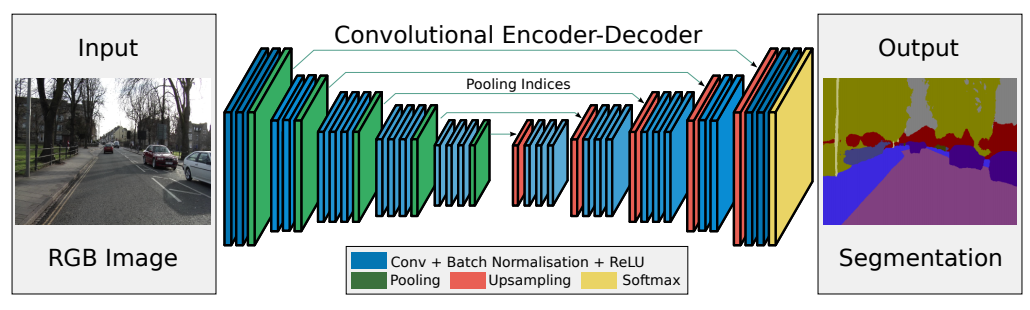

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [116]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.pool1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=(3, 3), padding=1), # (256, 256) -> (256, 256)
            nn.ReLU(),
            nn.BatchNorm2d(num_features=6),
            nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) # (256, 256) -> (128, 128)
        )
        self.pool2 = nn.Sequential(
            nn.Conv2d(in_channels=6, out_channels=12, kernel_size=(3, 3), padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(12),
            nn.Conv2d(in_channels=12, out_channels=12, kernel_size=(3, 3), padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(12),
            nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) # -> 64
        )
        self.pool3 = nn.Sequential(
            nn.Conv2d(in_channels=12, out_channels=24, kernel_size=(3, 3), padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(24),
            nn.Conv2d(in_channels=24, out_channels=24, kernel_size=(3, 3), padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(24),
            nn.Conv2d(in_channels=24, out_channels=24, kernel_size=(3, 3), padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(24),
            nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) # -> 32
        )
        self.pool4 = nn.Sequential(
            nn.Conv2d(in_channels=24, out_channels=48, kernel_size=(3, 3), padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(48),
            nn.Conv2d(in_channels=48, out_channels=48, kernel_size=(3, 3), padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(48),
            nn.Conv2d(in_channels=48, out_channels=48, kernel_size=(3, 3), padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(48),
            nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) # -> 16
        )
        self.pool5 = nn.Sequential(
            nn.Conv2d(in_channels=48, out_channels=96, kernel_size=(3, 3), padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(96),
            nn.Conv2d(in_channels=96, out_channels=96, kernel_size=(3, 3), padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(96),
            nn.Conv2d(in_channels=96, out_channels=96, kernel_size=(3, 3), padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(96),
            nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) # (16, 16) -> (8, 8)
        )

        self.unpool1 = nn.MaxUnpool2d(kernel_size=2, stride=2) # (8, 8) -> (16, 16)
        self.deconv1 = nn.Sequential(
            nn.Conv2d(96, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.Conv2d(96, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.Conv2d(96, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU()
        )
        self.unpool2 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.deconv2 = nn.Sequential(
            nn.Conv2d(48, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.Conv2d(48, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.Conv2d(48, 24, kernel_size=3, padding=1),
            nn.BatchNorm2d(24),
            nn.ReLU()
        )
        self.unpool3 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.deconv3 = nn.Sequential(
            nn.Conv2d(24, 24, kernel_size=3, padding=1),
            nn.BatchNorm2d(24),
            nn.ReLU(),
            nn.Conv2d(24, 24, kernel_size=3, padding=1),
            nn.BatchNorm2d(24),
            nn.ReLU(),
            nn.Conv2d(24, 12, kernel_size=3, padding=1),
            nn.BatchNorm2d(12),
            nn.ReLU()
        )
        self.unpool4 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.deconv4 = nn.Sequential(
            nn.Conv2d(12, 12, kernel_size=3, padding=1),
            nn.BatchNorm2d(12),
            nn.ReLU(),
            nn.Conv2d(12, 6, kernel_size=3, padding=1),
            nn.BatchNorm2d(6),
            nn.ReLU()
        )
        self.unpool5 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.deconv5 = nn.Sequential(
            nn.Conv2d(6, 1, kernel_size=3, padding=1)
        )
        
    def forward(self, x):
        x, ind1 = self.pool1(x)
        x, ind2 = self.pool2(x)
        x, ind3 = self.pool3(x)
        x, ind4 = self.pool4(x)
        x, ind5 = self.pool5(x)

        x = self.deconv1(self.unpool1(x, ind5))
        x = self.deconv2(self.unpool2(x, ind4))
        x = self.deconv3(self.unpool3(x, ind3))
        x = self.deconv4(self.unpool4(x, ind2))
        x = self.deconv5(self.unpool5(x, ind1))

        return x


In [186]:
model = MyModel().to(device)
criterion = torch.nn.BCEWithLogitsLoss(reduction='mean')
optimizer = torch.optim.Adamax(model.parameters())

In [187]:
from tqdm import tqdm

def train(trloader, valloader, model, criterion, optimizer, device, epoch=20):
    model.to(device)
    history = {'train_loss': [], 'val_loss': []}

    for e in tqdm(range(epoch)):
        model.train()
        train_losses = []
        for x, y in trloader:
            x, y = x.to(device).float(), y.to(device).float()[:, None, :, :]
            optimizer.zero_grad()
            y_pred = model(x)
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
        train_loss = np.mean(train_losses)

        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_val, y_val in valloader:
                x_val, y_val = x_val.to(device).float(), y_val.to(device).float()[:, None, :, :]
                y_val_pred = model(x_val)
                val_loss = criterion(y_val_pred, y_val)
                val_losses.append(val_loss.item())
        val_loss = np.mean(val_losses)

        print(f'Epoch {e+1}/{epoch} Train Loss: {train_loss:.4f} Validation Loss: {val_loss:.4f}')
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

    return history


In [188]:
history = train(tr_dataloader, va_dataloader, model, criterion, optimizer, device)

  5%|▌         | 1/20 [00:01<00:26,  1.38s/it]

Epoch 1/20 Train Loss: 0.6532 Validation Loss: 0.6712


 10%|█         | 2/20 [00:02<00:24,  1.35s/it]

Epoch 2/20 Train Loss: 0.5933 Validation Loss: 0.6043


 15%|█▌        | 3/20 [00:04<00:22,  1.35s/it]

...

Epoch 18/20 Train Loss: 0.1856 Validation Loss: 0.1837


 95%|█████████▌| 19/20 [00:25<00:01,  1.35s/it]

Epoch 19/20 Train Loss: 0.1928 Validation Loss: 0.1970


100%|██████████| 20/20 [00:26<00:00,  1.35s/it]

Epoch 20/20 Train Loss: 0.1893 Validation Loss: 0.1994


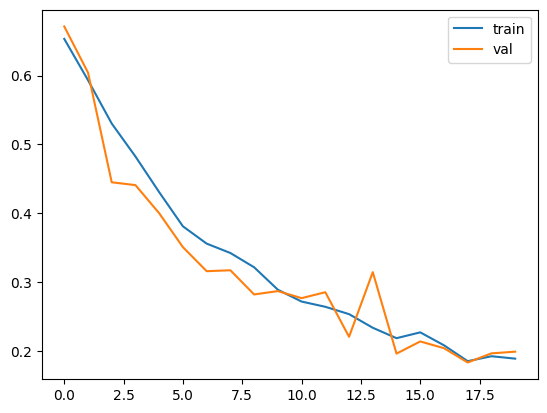

In [189]:
plt.plot(range(20), history['train_loss'], label='train')
plt.plot(range(20), history['val_loss'], label='val')
plt.legend()

### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

## U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

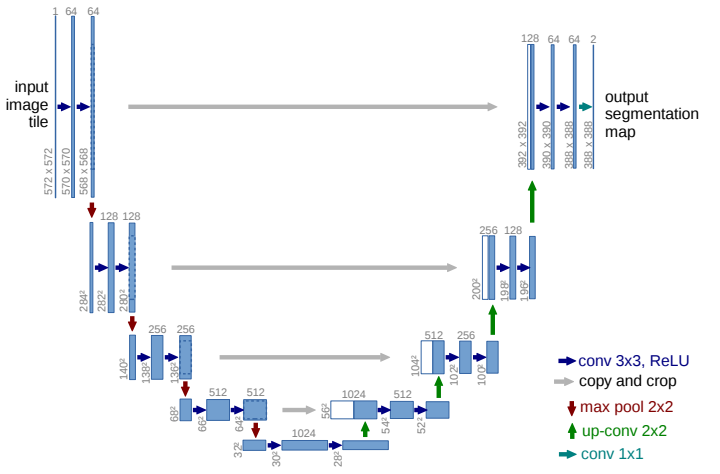

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.